In [1]:
import os
print(os.listdir("../data"))

['baseline_data.csv', 'production_data.csv']


In [2]:
import sys
import os
print(os.getcwd())
sys.path.append(os.path.abspath("../src"))

C:\Users\Bender\Desktop\ml-model-monitoring\notebooks


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from monitoring.drift_detection import detect_feature_drift

In [14]:
production_data = pd.DataFrame({
    "feature1":[1.8,1.7,1.9,1.6],
    "feature2":[4.1,4.0,4.2,3.9],
    "bytes_transferred":[900,880,920,870]
})

production_data.to_csv("../data/production_data.csv", index=False)

In [15]:
train = pd.read_csv("../data/baseline_data.csv")
prod = pd.read_csv("../data/production_data.csv")

train.head()

,feature1,feature2,bytes_transferred
0,1.2,3.4,500
1,1.1,3.6,520
2,1.3,3.5,510
3,1.0,3.3,495


In [6]:
for column in train.columns:
    p_value = detect_feature_drift(train[column], prod[column])
    print(column, p_value)

feature1 0.028571428571428577
feature2 0.028571428571428577
bytes_transferred 0.028571428571428577


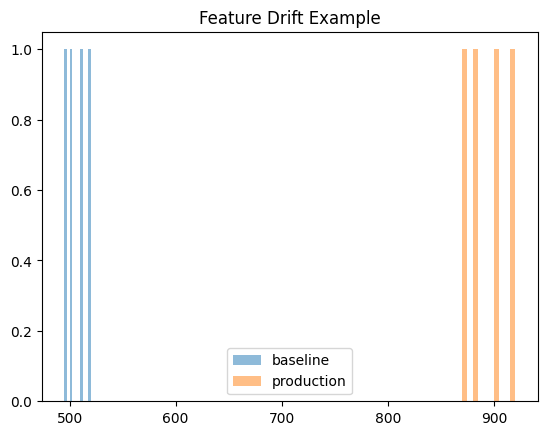

In [7]:
plt.hist(train["bytes_transferred"], alpha=0.5, label="baseline")
plt.hist(prod["bytes_transferred"], alpha=0.5, label="production")

plt.legend()
plt.title("Feature Drift Example")

plt.show()

In [8]:
plt.savefig("../metrics/drift_example.png")

<Figure size 640x480 with 0 Axes>

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
time = np.arange(1, 11)

anomaly_rate = [0.03,0.04,0.03,0.05,0.06,0.07,0.08,0.09,0.11,0.12]
drift_score = [0.01,0.02,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09]
data_volume = [500,520,510,530,550,570,590,610,640,660]

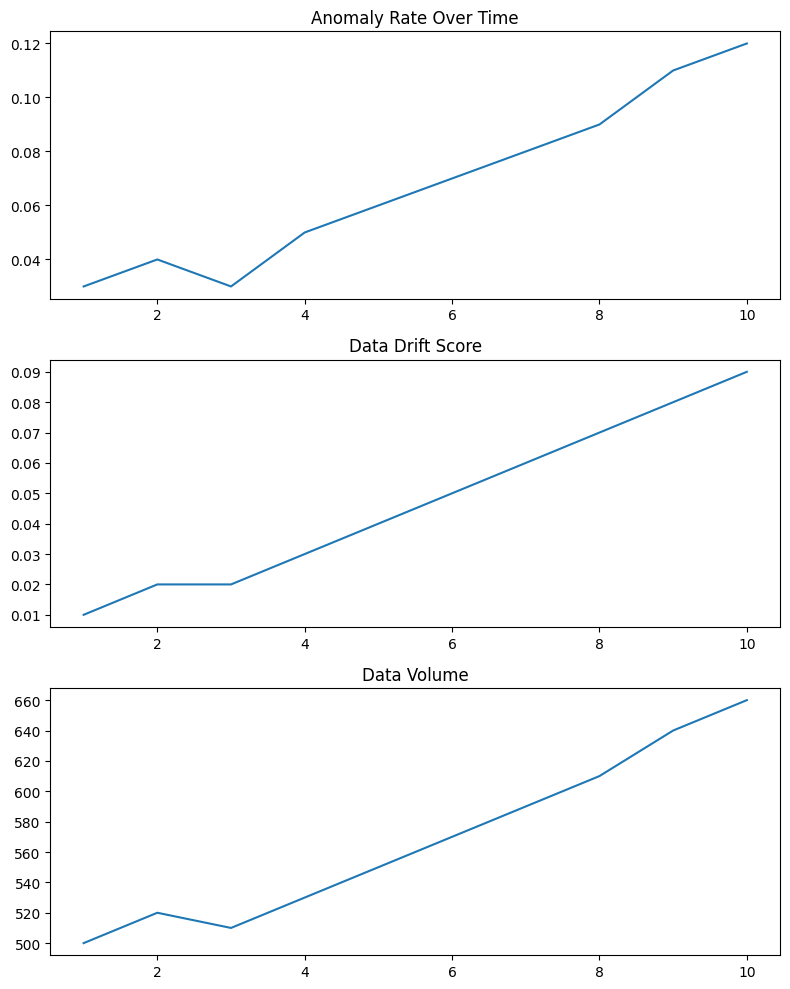

In [11]:
fig, axs = plt.subplots(3, 1, figsize=(8,10))

axs[0].plot(time, anomaly_rate)
axs[0].set_title("Anomaly Rate Over Time")

axs[1].plot(time, drift_score)
axs[1].set_title("Data Drift Score")

axs[2].plot(time, data_volume)
axs[2].set_title("Data Volume")

plt.tight_layout()
plt.show()

In [12]:
fig.savefig("../metrics/monitoring_dashboard.png")